<a href="https://colab.research.google.com/github/hamidafzal/riparian-restoration-Causal-Effect/blob/main/Danube_Causal_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Danube Riparian Forest Restoration — Causal Inference Pipeline
## Slovak Danube Floodplain | 1985–2024

Reproducible code for the causal inference analysis reported in:

> [Afzali et al.]. *Climate variability and forest management as drivers of vegetation health in the riparian zone of the Danube.* Environmental Research Letters, 2026.


---

## Quick start

In [1]:
# Core packages
!pip install -q \
    pandas>=1.5.0 \
    numpy>=1.23.0 \
    statsmodels>=0.14.0 \
    scikit-learn>=1.2.0 \
    matplotlib>=3.6.0

# Optional — for Moran's I spatial autocorrelation test (Step 11)
# Uncomment if needed:
# !pip install -q libpysal esda

---



---

## Causal structure (DAG)



In [2]:
# ============================================================
# CELL 0 — IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False
})

try:
    from libpysal.weights import KNN
    from esda.moran import Moran
    SPATIAL_OK = True
    print('✓ libpysal + esda available')
except ImportError:
    SPATIAL_OK = False
    print('⚠  libpysal/esda not installed — Moran\'s I will be skipped')
    print('   pip install libpysal esda')

print('✓ Core imports OK')

✓ libpysal + esda available
✓ Core imports OK


In [7]:
# ============================================================
# CELL 1 — CONFIGURATION
# ============================================================

DATA_PATH = r'https://raw.githubusercontent.com/hamidafzal/riparian-restoration-Causal-Effect/main/data/sample.csv'

# Restoration year per reach (9999 = never restored = control)
RESTORE_MAP = {1: 2012, 2: 2019, 3: 9999, 4: 2015}
YEAR_RANGE  = range(1985, 2025)
PRE_AVG_YRS = 5       # years of pre-treatment history for PS covariates
GRID_SIZE   = 90       # metres — spatial cluster grid for robust SEs

# Period labels
PERIOD_KEYS   = ['Year0', 'yr1_2', 'yr3_5', 'yr6_10', 'gt10']
PERIOD_LABELS = ['Year 0', '1–2 yr', '3–5 yr', '6–10 yr', '>10 yr']
PERIOD_BINS   = [-np.inf, -1, 0, 2, 5, 10, np.inf]
PERIOD_CATS   = ['Pre', 'Year0', 'yr1_2', 'yr3_5', 'yr6_10', 'gt10']

# Time-varying variables to melt from wide to long
# vhi        = z-scored AR1 residuals from remotePARTs (trend analysis only)
# vhi_regional = bounded [0,1] sub-regional VHI ← PRIMARY CAUSAL OUTCOME
MELT_VARS = ['vhi_regional', 'vhi', 'msi', 'tem', 'pre', 'discharge']

# Static per-pixel covariates (one value per pixel across all years)
STATIC_COVARS = ['distance_mainChannel', 'topo', 'forest_F']

# Variables for 5-yr pre-treatment mean computation
PRE_MEAN_VARS = ['vhi_regional', 'msi', 'pre', 'tem', 'discharge']


CONFOUNDERS = STATIC_COVARS + [f'{v}_premean' for v in PRE_MEAN_VARS]

OUTCOME = 'vhi_regional'   # PRIMARY outcome

print('✓ Configuration loaded')
print(f'  Data:        {DATA_PATH}')
print(f'  Outcome:     {OUTCOME}')
print(f'  Grid (SE):   {GRID_SIZE}m')
print(f'  Confounders: {CONFOUNDERS}')

✓ Configuration loaded
  Data:        https://raw.githubusercontent.com/hamidafzal/riparian-restoration-Causal-Effect/main/data/sample.csv
  Outcome:     vhi_regional
  Grid (SE):   90m
  Confounders: ['distance_mainChannel', 'topo', 'forest_F', 'vhi_regional_premean', 'msi_premean', 'pre_premean', 'tem_premean', 'discharge_premean']


---
## Step 1 · Load and reshape

In [8]:
# ── Load ──────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH)
df_raw['restoration_year'] = df_raw['reach_numb'].map(RESTORE_MAP)

print(f'Dataset: {df_raw.shape[0]:,} pixels | {df_raw.shape[1]} columns')
print(f'\nReach distribution:')
print(df_raw['reach_numb'].value_counts().sort_index().to_frame('pixels'))



Dataset: 400 pixels | 410 columns

Reach distribution:
            pixels
reach_numb        
1              100
2              100
3              100
4              100


In [9]:
# ── Wide to long ──────────────────────────────────────────────────────────────


years = [y for y in YEAR_RANGE if f'vhi_{y}' in df_raw.columns]
print(f'Years: {years[0]}–{years[-1]}  ({len(years)} years)')

id_vars = ['id', 'reach_numb', 'restoration_year']
for col in ['X', 'Y', 'forest_type', 'distance_mainChannel',
            'distance_sideChannel', 'topo', 'forest_F']:
    if col in df_raw.columns:
        id_vars.append(col)

long_list = []
for var in MELT_VARS:
    vcols = [f'{var}_{y}' for y in years if f'{var}_{y}' in df_raw.columns]
    if not vcols:
        print(f'  ⚠  {var}: not found — skipping')
        continue
    m = (pd.melt(df_raw, id_vars=['id'], value_vars=vcols,
                 var_name='_yr', value_name=var)
           .assign(year=lambda d: d['_yr'].str.extract(r'(\d+)').astype(int))
           .drop(columns='_yr')
           .set_index(['id', 'year'])[[var]])
    long_list.append(m)
    print(f'  ✓  {var}  ({len(vcols)} years)')

df_long = long_list[0]
for ldf in long_list[1:]:
    df_long = df_long.join(ldf, how='left')
df_long = df_long.reset_index()

meta    = df_raw[id_vars].drop_duplicates('id')
df_long = df_long.merge(meta, on='id', how='left')
df_long = df_long.sort_values(['id', 'year']).reset_index(drop=True)

# Treatment columns
df_long['is_restored']   = (df_long['year'] >= df_long['restoration_year']).astype(int)
df_long['relative_year'] = df_long['year'] - df_long['restoration_year']

# Spatial grid for cluster-robust SE
if 'X' in df_long.columns and 'Y' in df_long.columns:
    df_long['spatial_cluster'] = (
        (df_long['X'] // GRID_SIZE).astype(int).astype(str)
        + '_'
        + (df_long['Y'] // GRID_SIZE).astype(int).astype(str)
    )
    print(f'\n✓  Spatial clusters: {df_long["spatial_cluster"].nunique():,} cells '
          f'({GRID_SIZE}m grid)')
else:
    df_long['spatial_cluster'] = df_long['id']  # fallback
    print('\n⚠  X/Y not found — spatial_cluster set to pixel id (fallback)')

print(f'\nLong format: {len(df_long):,} rows | {df_long.shape[1]} cols')
print('\nTreatment fraction by reach:')
print(df_long.groupby('reach_numb')['is_restored'].mean().round(3))

Years: 1985–2024  (40 years)
  ✓  vhi_regional  (40 years)
  ✓  vhi  (40 years)
  ✓  msi  (40 years)
  ✓  tem  (40 years)
  ✓  pre  (40 years)
  ✓  discharge  (40 years)

⚠  X/Y not found — spatial_cluster set to pixel id (fallback)

Long format: 16,000 rows | 18 cols

Treatment fraction by reach:
reach_numb
1    0.325
2    0.150
3    0.000
4    0.250
Name: is_restored, dtype: float64


---
## Step 2 · Validate VHI_regional

vhi_regional summary:
  Range:           0.0000 – 0.9862  (expected 0–1)
  Mean ± SD:       0.6146 ± 0.1728
  % outside [0,1]: 0.00%  ✓


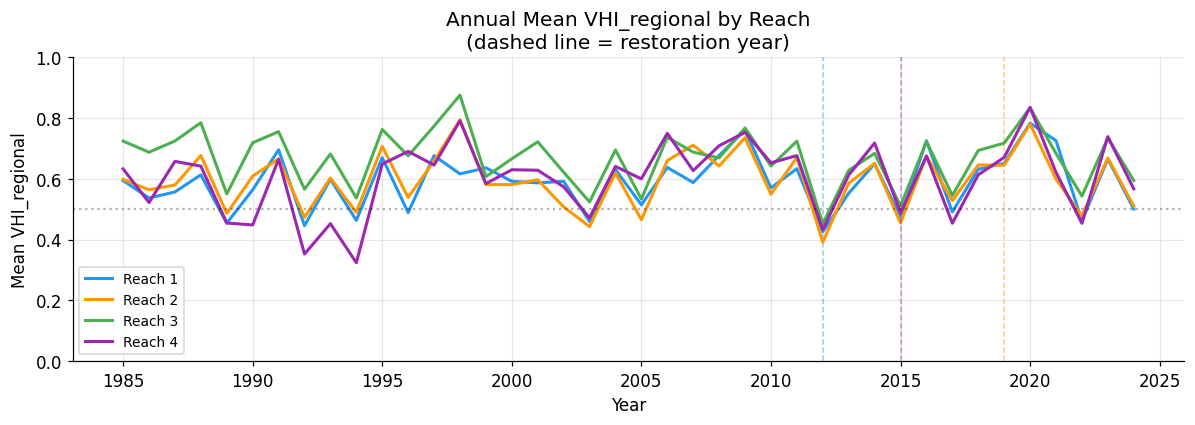

In [10]:
# vhi_regional is the PRIMARY causal outcome.


vals = df_long[OUTCOME].dropna()
print(f'{OUTCOME} summary:')
print(f'  Range:           {vals.min():.4f} – {vals.max():.4f}  (expected 0–1)')
print(f'  Mean ± SD:       {vals.mean():.4f} ± {vals.std():.4f}')
pct = ((vals<0)|(vals>1)).mean()*100
print(f'  % outside [0,1]: {pct:.2f}%  '
      f'{"✓" if pct==0 else "⚠  check edge fitting"}')

fig, ax = plt.subplots(figsize=(11, 4))
clr = {1:'#2196F3', 2:'#FF9800', 3:'#4CAF50', 4:'#9C27B0'}
for reach in sorted(df_long['reach_numb'].unique()):
    sub  = df_long[df_long['reach_numb']==reach]
    yr_m = sub.groupby('year')[OUTCOME].mean()
    ax.plot(yr_m.index, yr_m.values, color=clr[reach], lw=2,
            label=f'Reach {reach}')
    ry = RESTORE_MAP[reach]
    if ry < 9999:
        ax.axvline(ry, color=clr[reach], ls='--', lw=1, alpha=0.5)
ax.set(xlabel='Year', ylabel='Mean VHI_regional',
       title='Annual Mean VHI_regional by Reach\n(dashed line = restoration year)')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='k', ls=':', alpha=0.3)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 3 · Propensity score — modular functions



In [11]:
def compute_premeans(df_panel, vars_list, n_years=PRE_AVG_YRS):
    """
    One row per pixel.
    For treated pixels: mean of each variable over the last n_years BEFORE restoration.
    For control pixels (9999): mean over the last n_years of the full series.
    Returns cross-sectional DataFrame.
    """
    rows = []
    for pid, grp in df_panel.groupby('id'):
        rest_yr = grp['restoration_year'].iloc[0]
        pre = (grp[grp['year'] < rest_yr].tail(n_years)
               if rest_yr < 9999 else grp.tail(n_years))
        if len(pre) == 0:
            continue
        row = {
            'id': pid,
            'reach_numb':       grp['reach_numb'].iloc[0],
            'restoration_year': rest_yr,
            'is_treated':       int(rest_yr < 9999)
        }
        for v in vars_list:
            row[f'{v}_premean'] = pre[v].mean() if v in pre.columns else np.nan
        for s in STATIC_COVARS:
            if s in grp.columns:
                row[s] = grp[s].iloc[0]
        for extra in ['forest_type', 'spatial_cluster']:
            if extra in grp.columns:
                row[extra] = grp[extra].iloc[0]
        rows.append(row)
    return pd.DataFrame(rows)


def fit_ps(df_cs, confounders):
    """Logistic regression PS on cross-section. Adds 'ps' column."""
    avail  = [c for c in confounders if c in df_cs.columns]
    df_cs  = df_cs.dropna(subset=avail).copy()
    scaler = StandardScaler()
    X_ps   = scaler.fit_transform(df_cs[avail].astype(float))
    mdl    = LogisticRegression(C=1.0, max_iter=2000,
                                 solver='lbfgs', random_state=42)
    mdl.fit(X_ps, df_cs['is_treated'].values)
    df_cs['ps'] = mdl.predict_proba(X_ps)[:, 1]
    return df_cs


def compute_weights(df_cs, trim_pct=0.99):
    """
    Stabilized IPTW weights truncated at trim_pct.
    Also computes reach-balanced weights (sw_bal) — PRIMARY.
    """
    p_a = df_cs['is_treated'].mean()
    df_cs['sw_raw'] = np.where(
        df_cs['is_treated']==1,
        p_a / df_cs['ps'],
        (1-p_a) / (1-df_cs['ps'])
    )
    trunc = df_cs['sw_raw'].quantile(trim_pct)
    df_cs['sw'] = df_cs['sw_raw'].clip(upper=trunc)
    n_r   = df_cs['reach_numb'].nunique()
    rc_ct = df_cs.groupby('reach_numb')['id'].transform('count')
    df_cs['sw_bal'] = df_cs['sw'] * (len(df_cs) / (n_r * rc_ct))
    df_cs['sw_bal'] = df_cs['sw_bal'] / df_cs['sw_bal'].mean()
    return df_cs, trunc


def build_att_panel(df_p):
    """Add time_group, ATT interactions, reach FE to panel."""
    df_p = df_p.copy()
    df_p['time_group'] = pd.cut(
        df_p['relative_year'], bins=PERIOD_BINS,
        labels=PERIOD_CATS, ordered=True
    )
    td   = pd.get_dummies(df_p['time_group'], prefix='period', drop_first=False)
    df_p = pd.concat([df_p.reset_index(drop=True),
                       td.reset_index(drop=True)], axis=1)
    att_vars = []
    for p in PERIOD_KEYS:
        col = f'att_{p}'
        if f'period_{p}' in df_p.columns:
            df_p[col] = (df_p['is_restored'] * df_p[f'period_{p}']).astype(float)
            att_vars.append(col)
    rd     = pd.get_dummies(df_p['reach_numb'].astype(int),
                             prefix='reach', drop_first=False)
    rfe    = [c for c in rd.columns if c != 'reach_3']
    df_p   = pd.concat([df_p.reset_index(drop=True),
                         rd[rfe].reset_index(drop=True)], axis=1)
    return df_p, att_vars, rfe


def run_att(df, outcome, weight_col, att_vars, fe_vars, label, cluster_col=None):
    """
    WLS with HC3 (default) or spatial cluster-robust SE.
    Returns (fitted_model, results_dataframe).
    """
    av_att = [v for v in att_vars if v in df.columns]
    av_fe  = [v for v in fe_vars  if v in df.columns]
    X = sm.add_constant(df[av_att + av_fe].astype(float))

    if cluster_col and cluster_col in df.columns:
        m   = sm.WLS(df[outcome], X, weights=df[weight_col]).fit(
                  cov_type='cluster',
                  cov_kwds={'groups': df[cluster_col].values})
        se_tag = f'cluster SE [{cluster_col}]'
    else:
        m      = sm.WLS(df[outcome], X, weights=df[weight_col]).fit(cov_type='HC3')
        se_tag = 'HC3'

    print(f'\n{"="*68}')
    print(f'ATT — {label}   [{se_tag}]')
    print(f'  Intercept (Reach 3 baseline): {m.params["const"]:+.4f}')
    for r in av_fe:
        print(f'  FE {r}: {m.params.get(r,np.nan):+.4f}  '
              f'(p={m.pvalues.get(r,np.nan):.3f})')
    print(f'\n  {"Period":<12}{"Coef":>8}{"SE":>8}{"p":>7}{"95% CI":>22}{"Sig":>5}')
    print(f'  {"-"*63}')
    rows = []
    for pk, lbl in zip(PERIOD_KEYS, PERIOD_LABELS):
        v = f'att_{pk}'
        if v not in m.params.index:
            rows.append(dict(period=lbl, coef=np.nan, se=np.nan,
                             pval=np.nan, ci_low=np.nan, ci_high=np.nan,
                             significant=False))
            continue
        coef=m.params[v]; se=m.bse[v]; pval=m.pvalues[v]
        ci_l=m.conf_int().loc[v,0]; ci_h=m.conf_int().loc[v,1]
        sig = ('***' if pval<0.001 else '**' if pval<0.01
                else '*' if pval<0.05 else 'ns')
        print(f'  {lbl:<12}{coef:>+8.4f}{se:>8.4f}{pval:>7.3f}'
              f'  [{ci_l:+.4f},{ci_h:+.4f}]{sig:>5}')
        rows.append(dict(period=lbl, coef=coef, se=se, pval=pval,
                         ci_low=ci_l, ci_high=ci_h, significant=pval<0.05))
    return m, pd.DataFrame(rows)


print('✓  All functions defined')

✓  All functions defined


---
## Step 4 · Estimate propensity scores

In [12]:
print(f'Computing {PRE_AVG_YRS}-year pre-treatment means...')
df_cs = compute_premeans(df_long, PRE_MEAN_VARS)

avail_conf = [c for c in CONFOUNDERS if c in df_cs.columns]
missing    = [c for c in CONFOUNDERS if c not in df_cs.columns]
if missing:
    print(f'⚠  Missing confounders (not in data): {missing}')

df_cs = df_cs.dropna(subset=avail_conf).copy()

print(f'Cross-sectional dataset: {len(df_cs):,} pixels')
print(f'  Treated:  {df_cs["is_treated"].sum():,}')
print(f'  Control:  {(df_cs["is_treated"]==0).sum():,}')

df_cs, sw_99 = compute_weights(fit_ps(df_cs, avail_conf))

print(f'\nPS summary by group:')
print(df_cs.groupby('is_treated')['ps'].describe().round(3))
print(f'\nPositivity: PS<0.01: {(df_cs["ps"]<0.01).sum()} | '
      f'PS>0.99: {(df_cs["ps"]>0.99).sum()}')
print(f'  (99th pct weight truncation at {sw_99:.3f} — '
      f'controls extreme weights without discarding pixels)')
print(f'\nWeights:')
print(f'  sw     mean={df_cs["sw"].mean():.3f}  max={df_cs["sw"].max():.3f}')
print(f'  sw_bal mean={df_cs["sw_bal"].mean():.3f}  max={df_cs["sw_bal"].max():.3f}')

Computing 5-year pre-treatment means...
Cross-sectional dataset: 355 pixels
  Treated:  255
  Control:  100

PS summary by group:
            count   mean    std    min    25%    50%    75%    max
is_treated                                                        
0           100.0  0.385  0.276  0.028  0.138  0.318  0.637  0.913
1           255.0  0.849  0.190  0.108  0.794  0.930  0.988  1.000

Positivity: PS<0.01: 0 | PS>0.99: 53
  (99th pct weight truncation at 2.973 — controls extreme weights without discarding pixels)

Weights:
  sw     mean=0.848  max=2.973
  sw_bal mean=1.000  max=4.594


---
## Step 5 · VIF check

In [13]:
X_vif = sm.add_constant(df_cs[avail_conf].astype(float))
print('Variance Inflation Factors (>5 = concern, >10 = severe):')
print(f'{"Variable":<35}{"VIF":>8}')
print('-'*46)
for i, col in enumerate(X_vif.columns):
    if col == 'const': continue
    vif  = variance_inflation_factor(X_vif.values, i)
    flag = '  ⚠  HIGH' if vif>5 else '  ✓'
    print(f'{col:<35}{vif:>8.2f}{flag}')

Variance Inflation Factors (>5 = concern, >10 = severe):
Variable                                VIF
----------------------------------------------
distance_mainChannel                   1.34  ✓
topo                                   2.21  ✓
forest_F                               2.64  ✓
vhi_regional_premean                   4.45  ✓
msi_premean                            3.19  ✓
pre_premean                            3.02  ✓
tem_premean                            3.13  ✓
discharge_premean                      2.93  ✓


In [ ]:
# TO_DROP = ['vhi_regional_premean', 'msi_premean', 'forest_F']

# CONFOUNDERS_UPDATED = [c for c in avail_conf if c not in TO_DROP]
# # Re-run PS with updated confounders
# df_cs = df_cs.drop(columns=['ps','sw_raw','sw','sw_bal'], errors='ignore')
# df_cs = fit_ps(df_cs, CONFOUNDERS_UPDATED)
# df_cs, sw_99 = compute_weights(df_cs)

# print('Re-estimated PS with updated confounders:')
# print(df_cs.groupby('is_treated')['ps'].describe().round(3))

# # Update avail_conf so placebo and balance checks use the same list
# avail_conf = CONFOUNDERS_UPDATED

In [ ]:
# # ── Re-estimate PS with updated confounders ───────────────────────────────────
# df_cs = df_cs.drop(columns=['ps','sw_raw','sw','sw_bal'], errors='ignore')
# df_cs = fit_ps(df_cs, CONFOUNDERS_UPDATED)
# df_cs, sw_99 = compute_weights(df_cs)
# avail_conf = CONFOUNDERS_UPDATED

# print(df_cs.groupby('is_treated')['ps'].describe().round(3))

---
## Step 6 · Covariate balance

Covariate                            Before   After  Status
------------------------------------------------------------
distance_mainChannel                 -0.231  -0.167  ✓
topo                                  0.467   0.205  ⚠  IMBALANCED
forest_F                             -1.514  -0.957  ⚠  IMBALANCED
vhi_regional_premean                 -0.490  -0.406  ⚠  IMBALANCED
msi_premean                           0.661   0.563  ⚠  IMBALANCED
pre_premean                           0.193   0.137  ✓
tem_premean                           0.739   0.214  ⚠  IMBALANCED
discharge_premean                     0.341   0.255  ⚠  IMBALANCED

Variables above |SMD|=0.2 after IPTW: 6


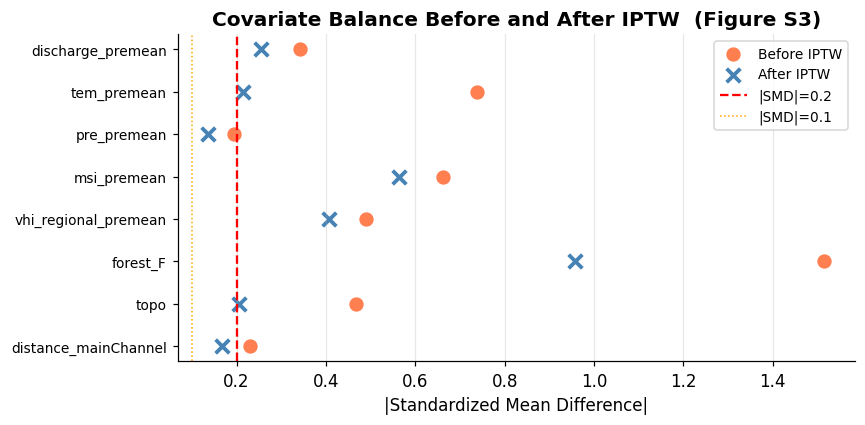

In [14]:
def smd(df, covs, treat='is_treated', w=None):
    t=df[df[treat]==1]; c=df[df[treat]==0]
    rows=[]
    for cov in covs:
        if cov not in df.columns: continue
        if w:
            tm=np.average(t[cov],weights=t[w]); cm=np.average(c[cov],weights=c[w])
            tv=np.average((t[cov]-tm)**2,weights=t[w]); cv=np.average((c[cov]-cm)**2,weights=c[w])
        else:
            tm,cm=t[cov].mean(),c[cov].mean(); tv,cv=t[cov].var(),c[cov].var()
        sd=np.sqrt((tv+cv)/2)
        rows.append({'covariate':cov,'smd':(tm-cm)/sd if sd>0 else 0})
    return pd.DataFrame(rows)

bal = smd(df_cs, avail_conf).rename(columns={'smd':'before'}).merge(
      smd(df_cs, avail_conf, w='sw').rename(columns={'smd':'after'}),
      on='covariate')

print(f'{"Covariate":<35}{"Before":>8}{"After":>8}  Status')
print('-'*60)
for _, r in bal.iterrows():
    st = '✓' if abs(r['after'])<0.2 else '⚠  IMBALANCED'
    print(f'{r["covariate"]:<35}{r["before"]:>8.3f}{r["after"]:>8.3f}  {st}')
print(f'\nVariables above |SMD|=0.2 after IPTW: {(bal["after"].abs()>0.2).sum()}')

fig, ax = plt.subplots(figsize=(8, 4))
y = range(len(bal))
ax.scatter(bal['before'].abs(), y, color='coral',     s=70, marker='o', label='Before IPTW')
ax.scatter(bal['after'].abs(),  y, color='steelblue', s=80, marker='x',
           linewidths=2.5, label='After IPTW')
ax.axvline(0.2, color='red',    ls='--', lw=1.5, label='|SMD|=0.2')
ax.axvline(0.1, color='orange', ls=':',  lw=1.0, label='|SMD|=0.1')
ax.set_yticks(list(y))
ax.set_yticklabels(bal['covariate'], fontsize=9)
ax.set_xlabel('|Standardized Mean Difference|')
ax.set_title('Covariate Balance Before and After IPTW  (Figure S3)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 7 · Build panel and ATT specification

In [15]:
# Merge pixel-level weights into the panel
weight_map = df_cs.set_index('id')[['sw', 'sw_bal']]
df_panel   = df_long.join(weight_map, on='id', how='left')
df_panel   = df_panel.dropna(subset=[OUTCOME, 'sw']).copy().reset_index(drop=True)

print(f'Panel: {len(df_panel):,} pixel-year obs | {df_panel["id"].nunique():,} pixels')
print(f'\nPer-reach:')
print(df_panel.groupby('reach_numb').agg(
    pixels=('id','nunique'),
    obs=(OUTCOME,'count'),
    pct_treated=('is_restored', lambda x: f'{x.mean()*100:.1f}%')
))

# ATT specification
df_panel, ATT_VARS, REACH_FE = build_att_panel(df_panel)
print(f'\nATT treated pixel-years per period:')
for v in ATT_VARS:
    print(f'  {v}: {int(df_panel[v].sum()):,}')
print(f'\nReach FE (reference = Reach 3, managed): {REACH_FE}')

Panel: 14,200 pixel-year obs | 355 pixels

Per-reach:
            pixels   obs pct_treated
reach_numb                          
1               90  3600       32.5%
2               98  3920       15.0%
3              100  4000        0.0%
4               67  2680       25.0%

ATT treated pixel-years per period:
  att_Year0: 255
  att_yr1_2: 510
  att_yr3_5: 765
  att_yr6_10: 718
  att_gt10: 180

Reach FE (reference = Reach 3, managed): ['reach_1', 'reach_2', 'reach_4']


---
## Step 8 · ATT models

In [16]:
# Model A — Standard IPTW + HC3
model_A, att_A = run_att(df_panel, OUTCOME, 'sw',
                          ATT_VARS, REACH_FE,
                          'Model A — Standard IPTW')


ATT — Model A — Standard IPTW   [HC3]
  Intercept (Reach 3 baseline): +0.6671
  FE reach_1: -0.0506  (p=0.000)
  FE reach_2: -0.0516  (p=0.000)
  FE reach_4: +0.0068  (p=0.139)

  Period          Coef      SE      p                95% CI  Sig
  ---------------------------------------------------------------
  Year 0       -0.0625  0.0095  0.000  [-0.0812,-0.0439]  ***
  1–2 yr       +0.0312  0.0074  0.000  [+0.0166,+0.0458]  ***
  3–5 yr       -0.0033  0.0059  0.579  [-0.0149,+0.0083]   ns
  6–10 yr      +0.0264  0.0065  0.000  [+0.0137,+0.0391]  ***
  >10 yr       -0.0057  0.0116  0.622  [-0.0285,+0.0170]   ns


In [17]:
# Model B — Reach-Balanced IPTW + HC3
model_B, att_B = run_att(df_panel, OUTCOME, 'sw_bal',
                          ATT_VARS, REACH_FE,
                          'Model B — Reach-Balanced IPTW  ★ PRIMARY')


ATT — Model B — Reach-Balanced IPTW  ★ PRIMARY   [HC3]
  Intercept (Reach 3 baseline): +0.6671
  FE reach_1: -0.0497  (p=0.000)
  FE reach_2: -0.0515  (p=0.000)
  FE reach_4: +0.0074  (p=0.106)

  Period          Coef      SE      p                95% CI  Sig
  ---------------------------------------------------------------
  Year 0       -0.0712  0.0093  0.000  [-0.0893,-0.0530]  ***
  1–2 yr       +0.0218  0.0077  0.005  [+0.0066,+0.0370]   **
  3–5 yr       +0.0056  0.0061  0.360  [-0.0064,+0.0177]   ns
  6–10 yr      +0.0201  0.0065  0.002  [+0.0074,+0.0327]   **
  >10 yr       -0.0066  0.0116  0.571  [-0.0294,+0.0162]   ns


In [18]:
# Reach-specific models
reach_rows = []; reach_mods = {}
for reach in [1, 2, 4]:
    df_r  = df_panel[df_panel['reach_numb']==reach].copy()
    if df_r['is_restored'].nunique() < 2: continue
    avail = [v for v in ATT_VARS if df_r[v].sum()>=10]
    if not avail: continue
    X_r = sm.add_constant(df_r[avail].astype(float))
    m_r = sm.WLS(df_r[OUTCOME], X_r, weights=df_r['sw']).fit(cov_type='HC3')
    reach_mods[reach] = m_r
    ry  = df_r['restoration_year'].iloc[0]
    ft  = df_r['forest_type'].iloc[0] if 'forest_type' in df_r.columns else '?'
    np_ = (df_r['is_restored']==0).sum()
    npo = (df_r['is_restored']==1).sum()
    print(f'\n{"─"*62}')
    print(f'Reach {reach} | type={ft} | restored {ry} | pre={np_:,} post={npo:,}')
    print(f'  Baseline: {m_r.params["const"]:+.4f}')
    for pk, lbl in zip(PERIOD_KEYS, PERIOD_LABELS):
        v = f'att_{pk}'
        if v not in avail: continue
        coef=m_r.params[v]; se=m_r.bse[v]; pval=m_r.pvalues[v]
        ci_l=m_r.conf_int().loc[v,0]; ci_h=m_r.conf_int().loc[v,1]
        sig = ('***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'ns')
        print(f'  {lbl:<10} {coef:>+8.4f}±{se:.4f} [{ci_l:+.4f},{ci_h:+.4f}] p={pval:.3f} {sig}')
        reach_rows.append(dict(reach=reach, period=lbl, forest_type=ft,
                               coef=coef, se=se, pval=pval,
                               ci_low=ci_l, ci_high=ci_h, significant=pval<0.05))
reach_df = pd.DataFrame(reach_rows)


──────────────────────────────────────────────────────────────
Reach 1 | type=102 | restored 2012 | pre=2,430 post=1,170
  Baseline: +0.6175
  Year 0      -0.1623±0.0147 [-0.1911,-0.1335] p=0.000 ***
  1–2 yr      +0.0184±0.0129 [-0.0070,+0.0437] p=0.156 ns
  3–5 yr      -0.0260±0.0116 [-0.0486,-0.0033] p=0.025 *
  6–10 yr     +0.0572±0.0088 [+0.0399,+0.0745] p=0.000 ***
  >10 yr      -0.0068±0.0117 [-0.0298,+0.0162] p=0.564 ns

──────────────────────────────────────────────────────────────
Reach 2 | type=102 | restored 2019 | pre=3,332 post=588
  Baseline: +0.6126
  Year 0      +0.0489±0.0098 [+0.0296,+0.0681] p=0.000 ***
  1–2 yr      +0.0946±0.0095 [+0.0760,+0.1132] p=0.000 ***
  3–5 yr      -0.0439±0.0075 [-0.0586,-0.0291] p=0.000 ***

──────────────────────────────────────────────────────────────
Reach 4 | type=101 | restored 2015 | pre=2,010 post=670
  Baseline: +0.6778
  Year 0      -0.1192±0.0135 [-0.1456,-0.0927] p=0.000 ***
  1–2 yr      -0.0509±0.0150 [-0.0803,-0.0216] p=0.

---
## Step 9 · Pre-treatment parallel trends

In [19]:
print(f'{"Period":<15}{"Treated (wtd)":>14}{"Control (wtd)":>14}{"Diff":>10}')
print('-'*56)
diffs = []
for lbl, lo, hi in [('Pre 1–2yr',-2,-1),('Pre 3–5yr',-5,-3),
                     ('Pre 6–10yr',-10,-6),('Pre >10yr',-9999,-11)]:
    sub = df_panel[df_panel['relative_year'].between(lo,hi)]
    tr  = sub[sub['restoration_year']<9999]
    co  = sub[sub['restoration_year']==9999]
    if len(tr)<5 or len(co)<5: continue
    tm  = np.average(tr[OUTCOME], weights=tr['sw'])
    cm  = np.average(co[OUTCOME], weights=co['sw'])
    d   = tm-cm; diffs.append(abs(d))
    print(f'{lbl:<15}{tm:>14.4f}{cm:>14.4f}{d:>+10.4f}')
if diffs:
    avg = np.mean(diffs)
    v   = '✓ Strong' if avg<0.03 else '✓ Acceptable' if avg<0.05 else '⚠  Check balance'
    print(f'\nMean |diff| = {avg:.4f}  →  {v}')

Period          Treated (wtd) Control (wtd)      Diff
--------------------------------------------------------
Pre >10yr              0.6256        0.6671   -0.0415

Mean |diff| = 0.0415  →  ✓ Acceptable


---
## Step 10 · Moran's I (requires X, Y)

In [21]:
HAS_COORDS = 'X' in df_panel.columns and 'Y' in df_panel.columns

if not SPATIAL_OK:
    print('⚠  libpysal/esda not installed. pip install libpysal esda')
elif not HAS_COORDS:
    print('⚠  X/Y not found in panel.')
    print('   Ensure X and Y are in the source CSV and that both column names match.')
else:
    X_res = sm.add_constant(df_panel[ATT_VARS+REACH_FE].astype(float))
    df_panel['residual_B'] = df_panel[OUTCOME].values - model_B.predict(X_res).values

    pix = (df_panel.groupby('id')
           .agg(mean_resid=('residual_B','mean'),
                X=('X','first'), Y=('Y','first'))
           .reset_index())

    w  = KNN.from_array(pix[['X','Y']].values, k=8)
    w.transform = 'R'
    mi = Moran(pix['mean_resid'].values, w)

    print('Global Moran\'s I on Model B residuals:')
    print(f'  I       = {mi.I:.4f}')
    print(f'  E[I]    = {mi.EI:.4f}  (expected under H0: no clustering)')
    print(f'  z-score = {mi.z_sim:.3f}')
    print(f'  p-value = {mi.p_sim:.4f}')

    if mi.p_sim > 0.05:
        print('\n✓  No significant spatial autocorrelation — HC3 SEs are valid.')
    else:
        print('\n⚠  Significant spatial clustering — proceeding to cluster-robust SEs (Step 12).')

⚠  X/Y not found in panel.
   Ensure X and Y are in the source CSV and that both column names match.


---
## Step 11 · Spatial cluster-robust SEs (30m grid)

In [22]:
n_cl = df_panel['spatial_cluster'].nunique()
print(f'Spatial clusters: {n_cl:,} grid cells ({GRID_SIZE}m)')
print(f'Mean pixels/cluster: {df_panel["id"].nunique()/n_cl:.1f}\n')

# Model B with spatial cluster-robust SE  ★ PRIMARY standard errors
model_B_sp, att_B_sp = run_att(
    df_panel, OUTCOME, 'sw_bal', ATT_VARS, REACH_FE,
    'Model B — Reach-Balanced + Spatial Cluster SE  ★ PRIMARY',
    cluster_col='spatial_cluster'
)

# Compare HC3 vs cluster-robust
print(f'\nSE comparison: HC3 vs spatial cluster-robust')
print(f'{"Period":<12}{"HC3 SE":>10}{"Cluster SE":>12}{"Ratio":>8}')
print('-'*46)
for pk, lbl in zip(PERIOD_KEYS, PERIOD_LABELS):
    v = f'att_{pk}'
    if v not in model_B.params.index: continue
    se_h = model_B.bse.get(v, np.nan)
    se_c = model_B_sp.bse.get(v, np.nan)
    ratio = se_c/se_h if se_h>0 else np.nan
    print(f'{lbl:<12}{se_h:>10.4f}{se_c:>12.4f}{ratio:>8.2f}x')
print('\nRatio > 1: cluster SE is more conservative (use this).')
print('Ratio ≈ 1: spatial dependence is negligible; HC3 was sufficient.')

Spatial clusters: 355 grid cells (90m)
Mean pixels/cluster: 1.0


ATT — Model B — Reach-Balanced + Spatial Cluster SE  ★ PRIMARY   [cluster SE [spatial_cluster]]
  Intercept (Reach 3 baseline): +0.6671
  FE reach_1: -0.0497  (p=0.001)
  FE reach_2: -0.0515  (p=0.000)
  FE reach_4: +0.0074  (p=0.629)

  Period          Coef      SE      p                95% CI  Sig
  ---------------------------------------------------------------
  Year 0       -0.0712  0.0082  0.000  [-0.0873,-0.0550]  ***
  1–2 yr       +0.0218  0.0068  0.001  [+0.0085,+0.0351]   **
  3–5 yr       +0.0056  0.0057  0.320  [-0.0055,+0.0167]   ns
  6–10 yr      +0.0201  0.0069  0.003  [+0.0066,+0.0335]   **
  >10 yr       -0.0066  0.0059  0.267  [-0.0182,+0.0051]   ns

SE comparison: HC3 vs spatial cluster-robust
Period          HC3 SE  Cluster SE   Ratio
----------------------------------------------
Year 0          0.0093      0.0082    0.89x
1–2 yr          0.0077      0.0068    0.88x
3–5 yr          0.0061      0.005

---
## Step 12 · E-value sensitivity analysis

In [23]:
baseline = model_B_sp.params['const']
print(f'E-Value Sensitivity  (Model B + spatial SE, baseline = {baseline:.4f})')
print(f'\n{"Period":<12}{"ATT":>8}{"Approx RR":>12}{"E-value":>10}{"Sig":>5}')
print('-'*53)
for _, row in att_B_sp.iterrows():
    if np.isnan(row['coef']): continue
    coef=row['coef']; pval=row['pval']
    rr = max(np.exp(coef/baseline), np.exp(-coef/baseline)) if baseline>0 else 1.0
    rr = max(rr, 1.0)
    ev = rr + np.sqrt(rr*(rr-1))
    sig= ('***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'ns')
    print(f'{row["period"]:<12}{coef:>+8.4f}{rr:>12.3f}{ev:>10.3f}  {sig}')
print()
print('E-value > 2.0 = moderate robustness | > 3.0 = strong')
print('Residual confounders after topo: soil texture, micro-scale GW variation')

E-Value Sensitivity  (Model B + spatial SE, baseline = 0.6671)

Period           ATT   Approx RR   E-value  Sig
-----------------------------------------------------
Year 0       -0.0712       1.113     1.466  ***
1–2 yr       +0.0218       1.033     1.219  **
3–5 yr       +0.0056       1.008     1.101  ns
6–10 yr      +0.0201       1.031     1.208  **
>10 yr       -0.0066       1.010     1.110  ns

E-value > 2.0 = moderate robustness | > 3.0 = strong
Residual confounders after topo: soil texture, micro-scale GW variation


---
## Step 13 · Event study plot

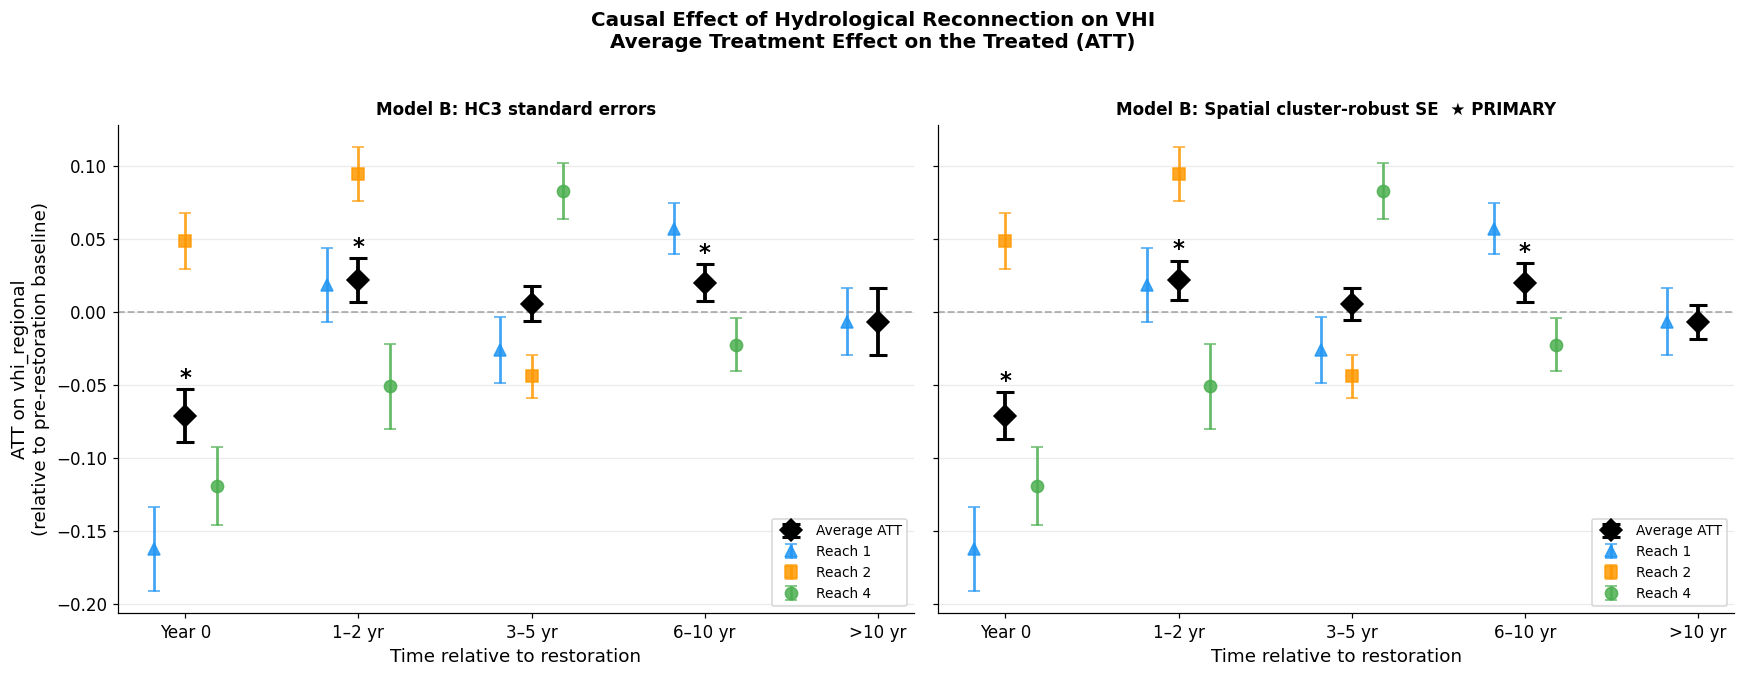

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
configs = [
    (att_B,    'Model B: HC3 standard errors'),
    (att_B_sp, 'Model B: Spatial cluster-robust SE  ★ PRIMARY'),
]
x   = np.arange(len(PERIOD_KEYS))
CLR = {1:'#2196F3', 2:'#FF9800', 4:'#4CAF50'}
MRK = {1:'^', 2:'s', 4:'o'}
OFF = {1:-0.18, 2:0.0, 4:0.18}

for ax, (att_df_plot, title) in zip(axes, configs):
    ay   = att_df_plot['coef'].values
    a_el = (att_df_plot['coef'] - att_df_plot['ci_low']).values
    a_eu = (att_df_plot['ci_high'] - att_df_plot['coef']).values

    ax.errorbar(x, ay, yerr=[np.nan_to_num(a_el), np.nan_to_num(a_eu)],
                fmt='D', color='black', ms=10, lw=2.5,
                capsize=6, capthick=2, label='Average ATT', zorder=5)

    for i, row in att_df_plot.iterrows():
        if row.get('significant', False) and not np.isnan(ay[i]):
            ax.text(x[i], ay[i]+a_eu[i]+0.003, '*',
                    ha='center', fontsize=15, fontweight='bold')

    for reach in [1, 2, 4]:
        rs = reach_df[reach_df['reach']==reach]
        if rs.empty: continue
        rx, ry, ry_el, ry_eu = [], [], [], []
        for i, p in enumerate(PERIOD_LABELS):
            row = rs[rs['period']==p]
            if not row.empty and not np.isnan(row['coef'].values[0]):
                rx.append(x[i]+OFF[reach]); ry.append(row['coef'].values[0])
                ry_el.append(row['coef'].values[0] - row['ci_low'].values[0])
                ry_eu.append(row['ci_high'].values[0] - row['coef'].values[0])
        if rx:
            ax.errorbar(rx, ry, yerr=[ry_el, ry_eu],
                        fmt=MRK[reach], color=CLR[reach],
                        ms=8, lw=1.8, capsize=4, alpha=0.85,
                        label=f'Reach {reach}')

    ax.axhline(0, color='gray', ls='--', lw=1.2, alpha=0.6)
    ax.set_xticks(x); ax.set_xticklabels(PERIOD_LABELS, fontsize=11)
    ax.set_xlabel('Time relative to restoration', fontsize=12)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='y', alpha=0.25)

axes[0].set_ylabel(f'ATT on {OUTCOME}\n(relative to pre-restoration baseline)', fontsize=12)
fig.suptitle('Causal Effect of Hydrological Reconnection on VHI\n'
             'Average Treatment Effect on the Treated (ATT)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()